Wilson Flores

Modifications from proposal:
1. Used a different dataset since original was unbalanced.
2. Finetuned BERT instead of training a neural network from scratch. I have chosen to use bert to because bert is pretrained on a big corpus.

Were you able to implement the solution you described?
I was able to implement the solution I described, but I decied to finetune bert.

Does your solution adequately address your real-world problem?
I would say so.

What metrics did you measure and what values for them did you achieve?
Accuracy, F1, Precision, and Recall. Above 90% for all but recall

In [295]:
import pandas as pd
from sklearn.model_selection import train_test_split
import kagglehub
import torch
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
import torch.nn as nn
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
import numpy as np
from transformers import BertTokenizerFast, AutoModel
import matplotlib.pyplot as plt

In [296]:
# Download latest version
path = kagglehub.dataset_download("bhavikjikadara/fake-news-detection")

print("Path to dataset files:", path)

# Load the dataset
dffake = pd.read_csv(path + "/fake.csv")
dftrue = pd.read_csv(path + "/true.csv")

# Add labels to the datasets
dffake['label'] = 1
dftrue['label'] = 0

# Combine the datasets
df = pd.concat([dffake, dftrue], ignore_index=True)

df['combined'] = df['title'] + " " + df['text']

df = df.drop(columns=['title', 'text', 'subject', 'date'])

Path to dataset files: /Users/wilsonflores/.cache/kagglehub/datasets/bhavikjikadara/fake-news-detection/versions/1


In [297]:
# 70% training, 15% testing, 15% validation
def split(X, y):

    # Split into training and temp (testing + validation)
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

    # Split temp into testing and validation
    X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

    return X_train, X_test, X_val, y_train, y_test, y_val

In [298]:
X_train, X_test, X_val, y_train, y_test, y_val = split(df['combined'], df['label'])

In [299]:
# Load BERT model and tokenizer with HuggingFace Transformers
bert = AutoModel.from_pretrained("prajjwal1/bert-small")
tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')

In [300]:
# Tokenize to Input IDs and attention masks
def tokenize_data(X_train, X_test, X_val, MAX_LENGHT):
    tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')
    # Tokenize the data
    tokens_train = tokenizer.batch_encode_plus(
        X_train.tolist(),
        max_length=MAX_LENGHT,
        padding=True,
        truncation=True
    )
    tokens_val = tokenizer.batch_encode_plus(
        X_val.tolist(),
        max_length=MAX_LENGHT,
        padding=True,
        truncation=True
    )
    tokens_test = tokenizer.batch_encode_plus(
        X_test.tolist(),
        max_length=MAX_LENGHT,
        padding=True,
        truncation=True
    )

    return tokens_train, tokens_val, tokens_test


In [301]:
# Convert lists to tensors
def convert_to_tensors(tokens_train, tokens_val, tokens_test):
    train_seq = torch.tensor(tokens_train['input_ids'])
    train_mask = torch.tensor(tokens_train['attention_mask'])
    train_y = torch.tensor(y_train.tolist())

    val_seq = torch.tensor(tokens_val['input_ids'])
    val_mask = torch.tensor(tokens_val['attention_mask'])
    val_y = torch.tensor(y_val.tolist())

    test_seq = torch.tensor(tokens_test['input_ids'])
    test_mask = torch.tensor(tokens_test['attention_mask'])
    test_y = torch.tensor(y_test.tolist())

    return train_seq, train_mask, train_y, val_seq, val_mask, val_y, test_seq, test_mask, test_y


In [302]:
# Create DataLoader for training and validation
def create_data_loader(train_seq, train_mask, train_y, val_seq, val_mask, val_y, test_seq, test_mask, test_y):

    train_data = TensorDataset(train_seq, train_mask, train_y)
    train_sampler = RandomSampler(train_data)
    train_dataloader = DataLoader(train_data, sampler=train_sampler, batch_size=128)

    val_data = TensorDataset(val_seq, val_mask, val_y)
    val_sampler = SequentialSampler(val_data)
    val_dataloader = DataLoader(val_data, sampler=val_sampler, batch_size=128)

    test_data = TensorDataset(test_seq, test_mask, test_y)
    test_sampler = SequentialSampler(test_data)
    test_dataloader = DataLoader(test_data, batch_size=128, sampler=SequentialSampler(test_data))

    return train_data, train_sampler, train_dataloader, val_data, val_sampler, val_dataloader, test_data, test_sampler, test_dataloader

In [303]:
tokens_train, tokens_val, tokens_test = tokenize_data(X_train, X_test, X_val, 512)

In [304]:
train_seq, train_mask, train_y, val_seq, val_mask, val_y, test_seq, test_mask, test_y = convert_to_tensors(tokens_train, tokens_val, tokens_test)

In [305]:
train_data, train_sampler, train_dataloader, val_data, val_sampler, val_dataloader, test_data, test_sampler, test_dataloader  = create_data_loader(train_seq, train_mask, train_y, val_seq, val_mask, val_y, test_seq, test_mask, test_y)

In [306]:
# Freezing the parameters
for param in bert.parameters():
    param.requires_grad = False  

In [307]:
class BERT_Arch(nn.Module):
    def __init__(self, bert):
        super(BERT_Arch, self).__init__()
        self.bert = bert
        # dropout layer
        self.dropout = nn.Dropout(0.1)           
        # relu activation function
        self.relu = nn.ReLU()                     
        self.fc1 = nn.Linear(512, 512) 
        # dense layer (Output layer)  
        self.fc2 = nn.Linear(512, 2)   
        # softmax activation function           
        self.softmax = nn.LogSoftmax(dim=1)      

    # define the forward pass
    def forward(self, sent_id, mask):             
        cls_hs = self.bert(sent_id, attention_mask=mask)['pooler_output']
        # pass the inputs to the model
        x = self.fc1(cls_hs)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)                           # output layer
        x = self.softmax(x)                       # apply softmax activation
        return x

model = BERT_Arch(bert)

# Defining the hyperparameters (optimizer, weights of the classes and the epochs)
# Define the optimizer
from torch.optim import AdamW
optimizer = AdamW(model.parameters(), lr = 1e-5)
# Define the loss function
cross_entropy  = nn.NLLLoss()
# Number of training epochs
epochs = 2

In [308]:
all_train_losses = []
all_val_losses = []
all_train_accuracies = []
all_val_accuracies = []

# Defining training and evaluation functions
def train():
  model.train()
  total_loss, total_accuracy = 0, 0
  # iterate over batches
  for step,batch in enumerate(train_dataloader):   
    # Progress update every 10 batches.             
    if step % 10 == 0 and not step == 0:
      print(f"Step {step}/{len(train_dataloader)}, Batch Accuracy: {batch_accuracy:.3f}")

    batch = [r for r in batch]                                  
    sent_id, mask, labels = batch
    # clear previously calculated gradients
    model.zero_grad()   
    # get model predictions for current batch                                        
    preds = model(sent_id, mask)     
    # compute loss between actual & predicted values                           
    loss = cross_entropy(preds, labels) 
    # add on to the total loss                        
    total_loss = total_loss + loss.item()    
    # backward pass to calculate the gradients                   
    loss.backward()    
    # preventing exploding gradient problem                                         
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    # update parameters     
    optimizer.step()

    # Calculate batch accuracy
    predss = torch.argmax(preds, dim=1)  # Get predicted class
    batch_accuracy = (predss == labels).sum().item() / len(labels)
    total_accuracy += batch_accuracy

    preds=preds.detach().cpu().numpy()                          
    all_train_losses.append(loss.item())  # append the loss
    all_train_accuracies.append(batch_accuracy)      
  avg_loss = total_loss / len(train_dataloader)                 
  
  return avg_loss

In [309]:
def evaluate():
  print("\nEvaluating...")
  model.eval()    
  total_loss, total_accuracy = 0, 0
  # Iterate over batches
  for step,batch in enumerate(val_dataloader): 
    # Progress update every 10 batches.
    if step % 10 == 0 and not step == 0:          
      print('  Batch {:>5,}  of  {:>5,}.'.format(step, len(val_dataloader)))
    batch = [t for t in batch]              
    sent_id, mask, labels = batch
    with torch.no_grad(): 
      # Model predictions       
      preds = model(sent_id, mask) 

      # Calculate batch accuracy
      predss = torch.argmax(preds, dim=1)  # Get predicted class
      batch_accuracy = (predss == labels).sum().item() / len(labels)
      total_accuracy += batch_accuracy

      # Compute the validation loss between actual and predicted values             
      loss = cross_entropy(preds,labels)        
      total_loss = total_loss + loss.item()
      preds = preds.detach().cpu().numpy()

    all_val_losses.append(loss.item())  
    all_val_accuracies.append(batch_accuracy)
  avg_loss = total_loss / len(val_dataloader)      
  return avg_loss

In [310]:
# Train and predict
best_valid_loss = float('inf')
train_losses=[]                   # empty lists to store training and validation loss of each epoch
valid_losses=[]

for epoch in range(epochs):
    print('\n Epoch {:} / {:}'.format(epoch + 1, epochs))
    train_loss = train()                       
    valid_loss = evaluate()                    
    if valid_loss < best_valid_loss:# save the best model
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'c2_new_model_weights.pt')
    # append training and validation loss
    train_losses.append(train_loss)           
    valid_losses.append(valid_loss)

    print(f'\nTraining Loss: {train_loss:.3f}')
    print(f'Validation Loss: {valid_loss:.3f}')


 Epoch 1 / 2
Step 10/246, Batch Accuracy: 0.664
Step 20/246, Batch Accuracy: 0.625
Step 30/246, Batch Accuracy: 0.672
Step 40/246, Batch Accuracy: 0.750
Step 50/246, Batch Accuracy: 0.797
Step 60/246, Batch Accuracy: 0.891
Step 70/246, Batch Accuracy: 0.836
Step 80/246, Batch Accuracy: 0.883
Step 90/246, Batch Accuracy: 0.875
Step 100/246, Batch Accuracy: 0.938
Step 110/246, Batch Accuracy: 0.852
Step 120/246, Batch Accuracy: 0.938
Step 130/246, Batch Accuracy: 0.914
Step 140/246, Batch Accuracy: 0.922
Step 150/246, Batch Accuracy: 0.883
Step 160/246, Batch Accuracy: 0.906
Step 170/246, Batch Accuracy: 0.969
Step 180/246, Batch Accuracy: 0.930
Step 190/246, Batch Accuracy: 0.922
Step 200/246, Batch Accuracy: 0.930
Step 210/246, Batch Accuracy: 0.961
Step 220/246, Batch Accuracy: 0.852
Step 230/246, Batch Accuracy: 0.930
Step 240/246, Batch Accuracy: 0.914

Evaluating...
  Batch    10  of     53.
  Batch    20  of     53.
  Batch    30  of     53.
  Batch    40  of     53.
  Batch    5

In [311]:
# load weights of best model
path = 'c2_new_model_weights.pt'
model.load_state_dict(torch.load(path))

<All keys matched successfully>

In [312]:
with torch.no_grad():
    all_preds = []
    for batch in test_dataloader:
        sent_id, mask, labels = batch
        preds = model(sent_id, mask)
        all_preds.append(preds.detach().cpu().numpy())
        print('loop: ', len(all_preds), 'of', len(test_dataloader))

loop:  1 of 53
loop:  2 of 53
loop:  3 of 53
loop:  4 of 53
loop:  5 of 53
loop:  6 of 53
loop:  7 of 53
loop:  8 of 53
loop:  9 of 53
loop:  10 of 53
loop:  11 of 53
loop:  12 of 53
loop:  13 of 53
loop:  14 of 53
loop:  15 of 53
loop:  16 of 53
loop:  17 of 53
loop:  18 of 53
loop:  19 of 53
loop:  20 of 53
loop:  21 of 53
loop:  22 of 53
loop:  23 of 53
loop:  24 of 53
loop:  25 of 53
loop:  26 of 53
loop:  27 of 53
loop:  28 of 53
loop:  29 of 53
loop:  30 of 53
loop:  31 of 53
loop:  32 of 53
loop:  33 of 53
loop:  34 of 53
loop:  35 of 53
loop:  36 of 53
loop:  37 of 53
loop:  38 of 53
loop:  39 of 53
loop:  40 of 53
loop:  41 of 53
loop:  42 of 53
loop:  43 of 53
loop:  44 of 53
loop:  45 of 53
loop:  46 of 53
loop:  47 of 53
loop:  48 of 53
loop:  49 of 53
loop:  50 of 53
loop:  51 of 53
loop:  52 of 53
loop:  53 of 53


In [313]:
preds = np.argmax(np.concatenate(all_preds, axis=0), axis=1)
print(classification_report(test_y, preds))

              precision    recall  f1-score   support

           0       0.87      0.98      0.92      3182
           1       0.98      0.87      0.92      3553

    accuracy                           0.92      6735
   macro avg       0.92      0.92      0.92      6735
weighted avg       0.93      0.92      0.92      6735



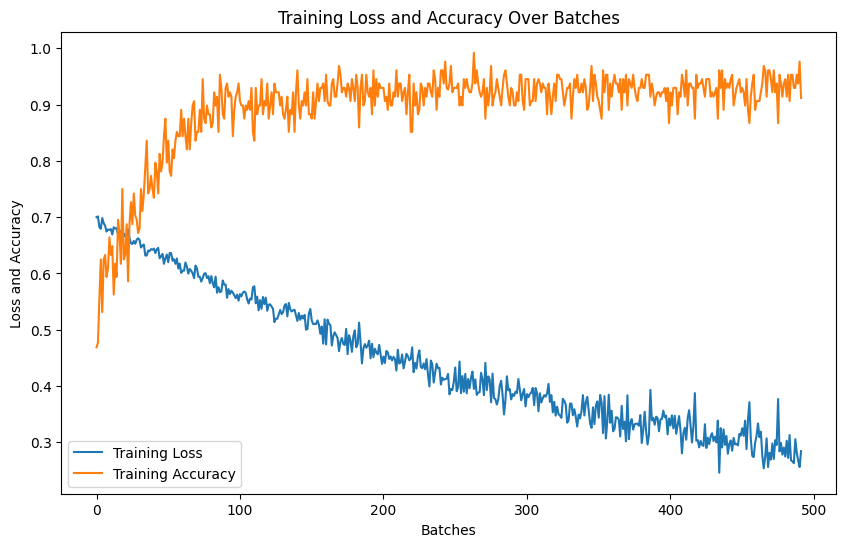

In [324]:
plt.figure(figsize=(10, 6))
plt.plot(all_train_losses, label='Training Loss')
plt.plot(all_train_accuracies, label='Training Accuracy')
plt.xlabel('Batches')
plt.ylabel('Loss and Accuracy')
plt.title('Training Loss and Accuracy Over Batches')
plt.legend()
plt.show()

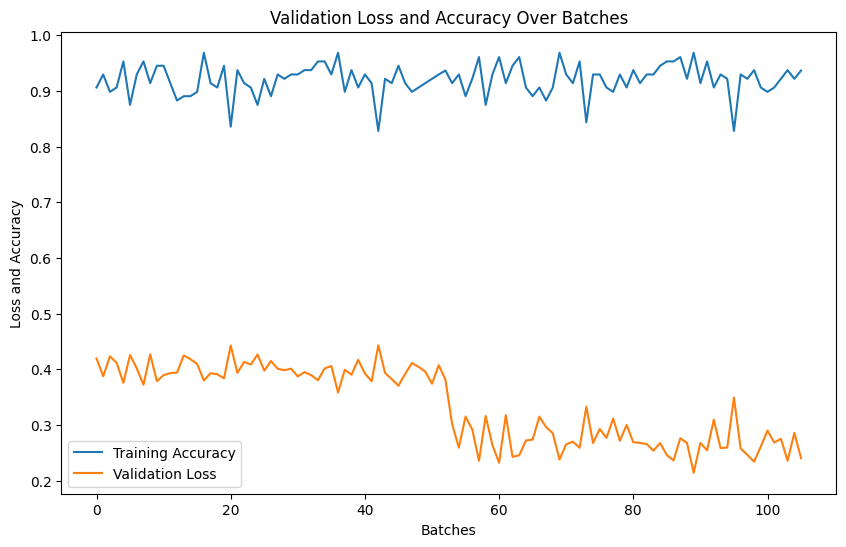

In [323]:
plt.figure(figsize=(10, 6))
plt.plot(all_val_accuracies, label='Training Accuracy')
plt.plot(all_val_losses, label='Validation Loss')
plt.xlabel('Batches')
plt.ylabel('Loss and Accuracy')
plt.title('Validation Loss and Accuracy Over Batches')
plt.legend()
plt.show()

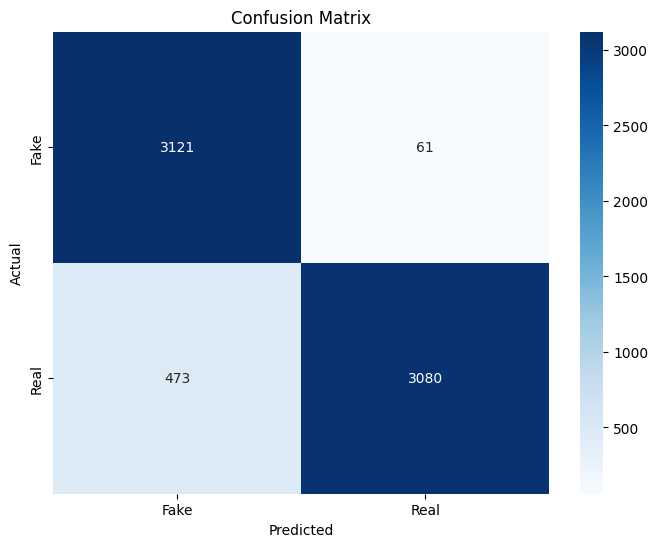

In [316]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(test_y, preds)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [322]:
# Final Metrics
accuracy = accuracy_score(test_y, preds)
precision = precision_score(test_y, preds)
recall = recall_score(test_y, preds)
f1 = f1_score(test_y, preds)
print("\nFinal Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")


Final Metrics:
Accuracy: 0.9207
Precision: 0.9806
Recall: 0.8669
F1 Score: 0.9202
